# Load library

In [1]:
import pandas as pd
import numpy as np

In [2]:
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [4]:
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud

In [5]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Loading dataset

In [6]:
df = pd.read_csv("data/spam.csv", encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## Shape

In [7]:
df.shape

(5572, 5)

## Column name

In [8]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [9]:
# Drop the extra columns and rename columns
df = df.drop(labels = ["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis = 1)
df.columns = ['label', 'message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Missing data

In [10]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [11]:
df = df.dropna()

## Duplicated rows

In [12]:
df.duplicated().sum()

403

In [13]:
df = df.drop_duplicates()

In [14]:
df.shape

(5169, 2)

# Explanatory Data Analysis (EDA)

## Check spam vs. ham distribution

In [15]:
## Counts
df['label'].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

In [16]:
## Percentage counts
df['label'].value_counts(normalize=True) * 100

label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64

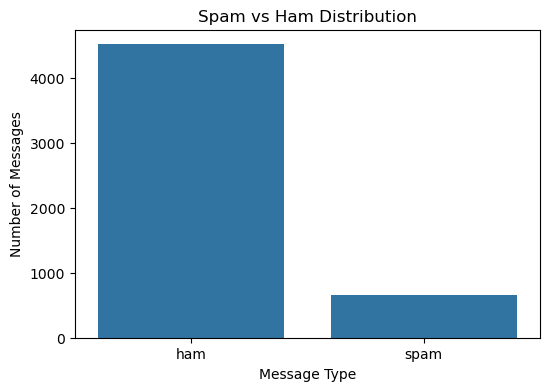

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='label')

plt.title("Spam vs Ham Distribution")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.show()

### Class Distribution

The dataset contains two classes: spam and ham. The ham class contains
significantly more messages than the spam class. Therefore, the dataset
is somewhat imbalanced. Accuracy alone should not be used to evaluate
the models because a model could achieve high accuracy while still
performing poorly at detecting spam.

## Length of messages

In [18]:
df['message_length'] = df['message'].apply(len)

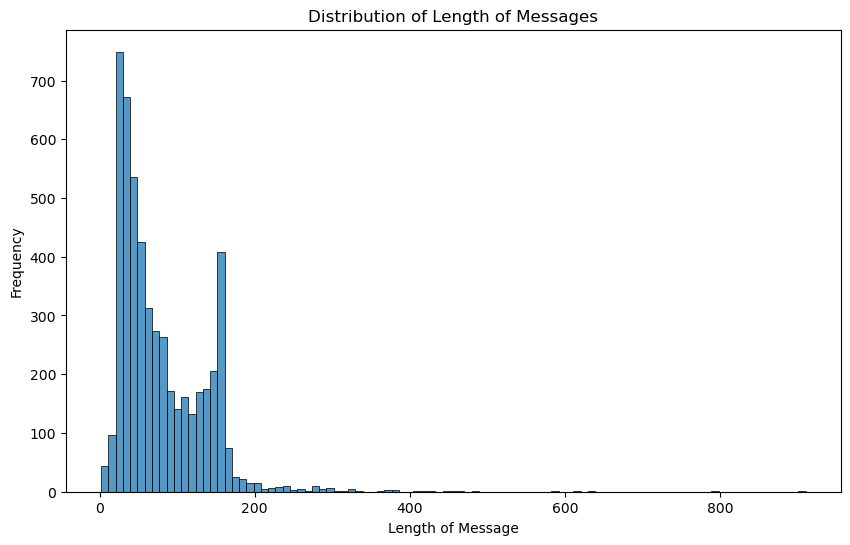

In [19]:
plt.figure(figsize=(10,6))

sns.histplot(data=df, x='message_length')

plt.title("Distribution of Length of Messages")
plt.xlabel("Length of Message")
plt.ylabel("Frequency")
plt.show()

## Length of message tokens

In [20]:
df['token_length'] =  (df['message'].str.split()).apply(len)

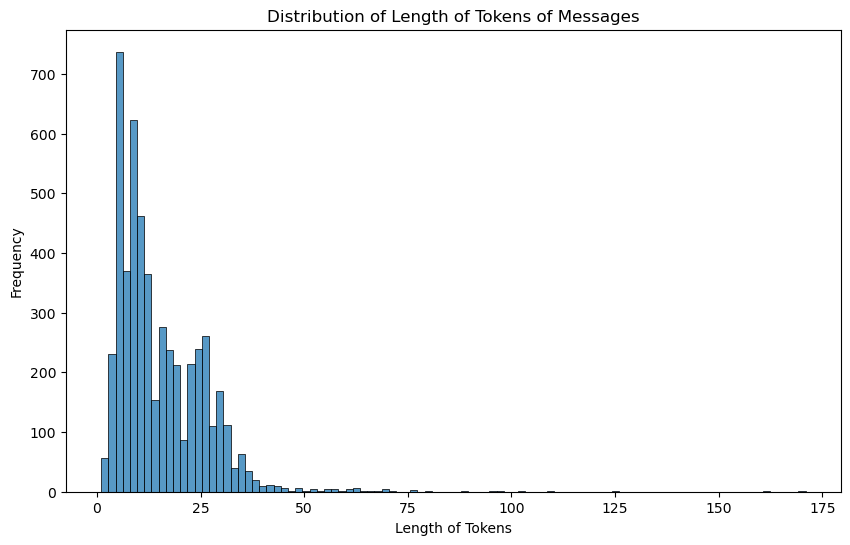

In [21]:
plt.figure(figsize=(10,6))

sns.histplot(data=df, x='token_length')

plt.title("Distribution of Length of Tokens of Messages")
plt.xlabel("Length of Tokens")
plt.ylabel("Frequency")
plt.show()

## Convert labels to numerical values

Convert:\
ham → 0\
spam → 1

In [22]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [23]:
df.head(3)

,label,message,message_length,token_length
0,0,"Go until jurong point, crazy.. Available only ...",111,20
1,0,Ok lar... Joking wif u oni...,29,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28


## Text preprocessing

In [24]:
stop_words = set(stopwords.words('english'))

In [25]:
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    return ' '.join(words)

In [26]:
sample = df['message'].iloc[0]

print("Original:")
print(sample)

print("\nProcessed:")
print(preprocess_text(sample))

Original:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Processed:
go jurong point crazy available bugis n great world la e buffet cine got amore wat


In [27]:
## Apply preprocessing to the entire dataset
df['clean_message'] = df['message'].apply(preprocess_text)

## Split the dataset into training and testing data

In [28]:
X = df['clean_message']
y = df['label']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.20, random_state=42, stratify=y)

In [30]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4135
Testing samples: 1034


## Feature extraction using TF-IDF

In [31]:
tfidf = TfidfVectorizer()

In [32]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [33]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4135, 7304)
Testing TF-IDF shape: (1034, 7304)


## TF-IDF Feature Extraction

TF-IDF stands for Term Frequency-Inverse Document Frequency.

It converts text into numerical values that represent how important a
word is within a document and across the entire collection of documents.

TF (Term Frequency) measures how frequently a word appears in a particular
document.

IDF (Inverse Document Frequency) reduces the importance of words that appear
in many documents and gives more importance to words that are relatively
rare across the dataset.

The TF-IDF value is calculated approximately as:

TF-IDF = TF × IDF

Therefore, words that occur frequently in a particular message but are not
common throughout the entire dataset receive higher weights.

TF-IDF is useful for spam detection because certain words and phrases can
be strong indicators of spam messages.


# Train Model 1 — Multinomial Naive Bayes

In [34]:
nb_model = MultinomialNB()

In [35]:
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [36]:
y_pred_nb = nb_model.predict(X_test_tfidf)

# Train Model 2 — Logistic Regression

In [37]:
lr_model = LogisticRegression(max_iter=1000)
# Train
lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [38]:
y_pred_lr = lr_model.predict(X_test_tfidf)

## Evaluate and Comparison of both Models: Naive Bayes and Logistic Regression

In [39]:
## y_pred of both model
y_preds = [y_pred_nb, y_pred_lr]

## Table for comparison of both model
result_dict = {'Model': ['Multinomial Naive Bayes','Logistic Regression'],
               'Accuracy': [accuracy_score(y_test, y_pred) for y_pred in y_preds],
               'Precision': [precision_score(y_test, y_pred) for y_pred in y_preds],
               'Recall': [recall_score(y_test, y_pred) for y_pred in y_preds],
               'F1-Score': [f1_score(y_test, y_pred) for y_pred in y_preds]
              }

results = pd.DataFrame(result_dict)
results

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.961315,0.989247,0.702290,0.821429
1,Logistic Regression,0.955513,0.988506,0.656489,0.788991


# Classification reports

In [40]:
print("Classification reports for Naive Bayes: \n  \n", classification_report(y_test, y_pred_nb,target_names=['Ham', 'Spam']))

Classification reports for Naive Bayes: 
  
               precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.99      0.70      0.82       131

    accuracy                           0.96      1034
   macro avg       0.97      0.85      0.90      1034
weighted avg       0.96      0.96      0.96      1034



In [41]:
print("Classification reports for Logistic Regression: \n  \n", classification_report(y_test, y_pred_lr,target_names=['Ham', 'Spam']))

Classification reports for Logistic Regression: 
  
               precision    recall  f1-score   support

         Ham       0.95      1.00      0.98       903
        Spam       0.99      0.66      0.79       131

    accuracy                           0.96      1034
   macro avg       0.97      0.83      0.88      1034
weighted avg       0.96      0.96      0.95      1034



## Confusion matrix for Naive Bayes

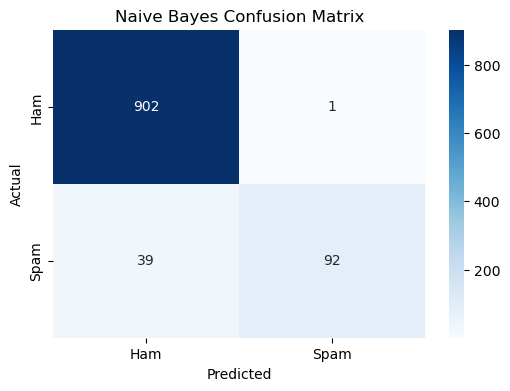

In [42]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")

plt.show()

## Confusion matrix for Logistic Regression

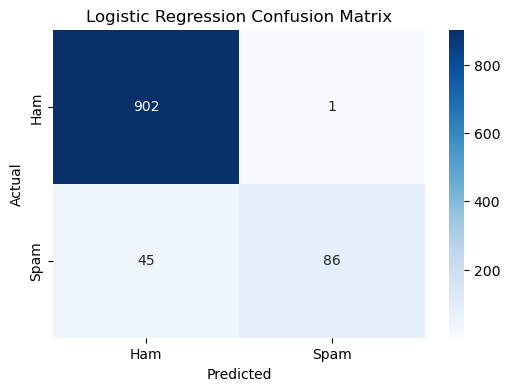

In [43]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

### Why is Recall Important for Spam Detection?

Recall is particularly important in spam detection because it measures the
proportion of actual spam messages that the model successfully identifies.

Recall is calculated as:

Recall = TP / (TP + FN)

A false negative occurs when an actual spam message is incorrectly classified
as legitimate (ham). This can allow unwanted, malicious, fraudulent, or
potentially dangerous messages to reach the user's inbox.

For example, if there are 100 spam messages and the classifier identifies
only 80 of them, its spam recall is 80%.

Therefore, a high recall means that the system is successful at detecting
most of the actual spam messages.

However, precision is also important. If the model classifies too many
legitimate messages as spam, important emails could be incorrectly sent to
the spam folder. Therefore, a good spam classifier should aim for a strong
balance between precision and recall, which can be summarized using the
F1-score.


# WordCloud for spam messages

In [44]:
spam_text = ' '.join(df[df['label'] == 1]['clean_message'])

In [45]:
spam_wordcloud = WordCloud(width=800, height=400, background_color='white'
                          ).generate(spam_text)

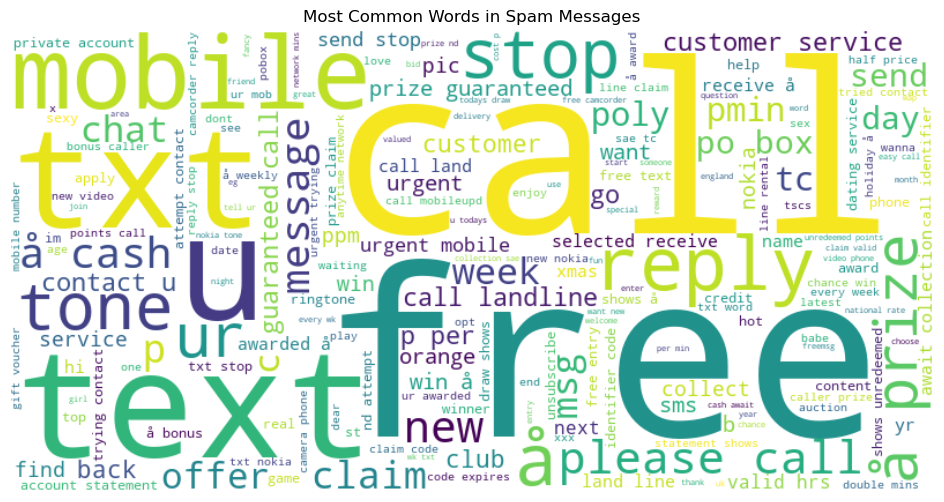

In [46]:
plt.figure(figsize=(12,6))

plt.imshow(spam_wordcloud, interpolation='bilinear')

plt.axis('off')
plt.title("Most Common Words in Spam Messages")

plt.show()

## WordCloud for ham messages

In [47]:
ham_text = ' '.join(df[df['label'] == 0]['clean_message'])

ham_wordcloud = WordCloud(width=800, height=400, background_color='white'
                          ).generate(ham_text)

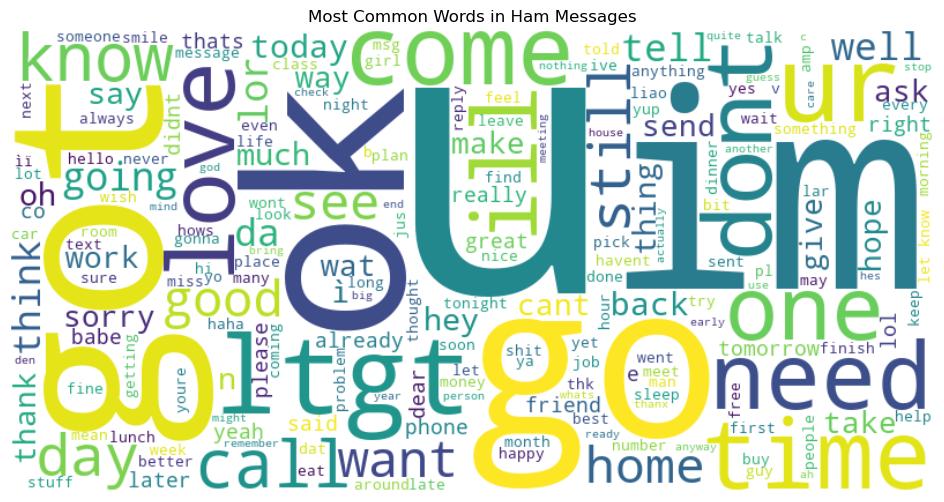

In [48]:
plt.figure(figsize=(12,6))

plt.imshow(ham_wordcloud, interpolation='bilinear')

plt.axis('off')
plt.title("Most Common Words in Ham Messages")

plt.show()


# Test your model with new messages

In [49]:
# Function for checking 
def predict_spam(message):
    cleaned_message = preprocess_text(message)
    message_tfidf = tfidf.transform([cleaned_message])
    
    prediction = lr_model.predict(message_tfidf)[0]
    
    if prediction == 1:
        return "SPAM"
    else:
        return "HAM"

In [50]:
# Examples

test_messages = [
    "Congratulations! You won $1000. Claim your prize now!",
    "Can you send me the assignment when you finish?",
    "URGENT! You have won a free vacation!",
    "I'll call you when I get home.",
    "Hey, are we still meeting for lunch tomorrow?"
]

for message in test_messages:
    print(message)
    print("Prediction:", predict_spam(message))
    print()


Congratulations! You won $1000. Claim your prize now!
Prediction: SPAM

Can you send me the assignment when you finish?
Prediction: HAM

URGENT! You have won a free vacation!
Prediction: SPAM

I'll call you when I get home.
Prediction: HAM

Hey, are we still meeting for lunch tomorrow?
Prediction: HAM

